In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
# Load the datasets
print("Loading datasets...")

# Load fake news data
fake_df = pd.read_csv('Fake.csv')
fake_df['label'] = 0  # 0 for fake news

# Load true news data
true_df = pd.read_csv('True.csv')
true_df['label'] = 1  # 1 for true news

print(f"Fake news dataset shape: {fake_df.shape}")
print(f"True news dataset shape: {true_df.shape}")

# Combine both datasets
df = pd.concat([fake_df, true_df], ignore_index=True)
print(f"Combined dataset shape: {df.shape}")

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Datasets loaded and combined successfully!")

Loading datasets...
Fake news dataset shape: (23481, 5)
True news dataset shape: (21417, 5)
Combined dataset shape: (44898, 5)
Datasets loaded and combined successfully!


In [4]:
# Import additional libraries for text processing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet

# Download required NLTK data
print("Downloading NLTK data...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("NLTK data downloaded successfully!")

NLTK data downloaded successfully!


In [5]:
# Basic Text Cleaning Functions

def remove_urls(text):
    """Remove URLs from text"""
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub('', text)

def remove_html_tags(text):
    """Remove HTML tags from text"""
    html_pattern = re.compile(r'<.*?>')
    return html_pattern.sub('', text)

def remove_emails(text):
    """Remove email addresses from text"""
    email_pattern = re.compile(r'\S+@\S+')
    return email_pattern.sub('', text)


## NOT Removing this as punctuations will help in determining tone of the news. Experiment done below to prove this
def remove_special_characters(text, keep_apostrophes=True):
    """Remove special characters while optionally keeping apostrophes for contractions"""
    if keep_apostrophes:
        # Keep apostrophes for contractions
        pattern = r'[^a-zA-Z0-9\s\']'
    else:
        pattern = r'[^a-zA-Z0-9\s]'
    return re.sub(pattern, '', text)

In [6]:
# Comprehensive Text Cleaning Pipeline

def clean_text_basic(text):
    """
    Basic text cleaning pipeline
    Suitable for models that need to preserve some original structure
    """
    if pd.isna(text):
        return ""

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove URLs, emails, and HTML tags
    text = remove_urls(text)
    text = remove_emails(text)
    text = remove_html_tags(text)
    text = remove_special_characters(text)

    return text

In [7]:
# Apply text cleaning to the dataset

print("Applying text cleaning to the dataset...")
print("This may take a few minutes for large datasets...")



# Apply different levels of cleaning
# Basic cleaning (good for neural networks)
df['title'] = df['title'].apply(clean_text_basic)
df['text'] = df['text'].apply(clean_text_basic)



print("Text cleaning completed!")
print(f"Dataset shape after adding cleaned columns: {df.shape}")
df.head()

Applying text cleaning to the dataset...
This may take a few minutes for large datasets...
Text cleaning completed!
Dataset shape after adding cleaned columns: (44898, 5)


,title,text,subject,date,label
0,ben stein calls out 9th circuit court committe...,21st century wire says ben stein reputable pro...,US_News,"February 13, 2017",0
1,trump drops steve bannon from national securit...,washington reuters us president donald trump ...,politicsNews,"April 5, 2017",1
2,puerto rico expects us to lift jones act shipp...,reuters puerto rico governor ricardo rossello...,politicsNews,"September 27, 2017",1
3,oops trump just accidentally confirmed he lea...,on monday donald trump once again embarrassed ...,News,"May 22, 2017",0
4,donald trump heads for scotland to reopen a go...,glasgow scotland reuters most us presidential...,politicsNews,"June 24, 2016",1


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [9]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred = nb_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9571269487750557

Confusion Matrix:
 [[4459  237]
 [ 148 4136]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96      4696
           1       0.95      0.97      0.96      4284

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980



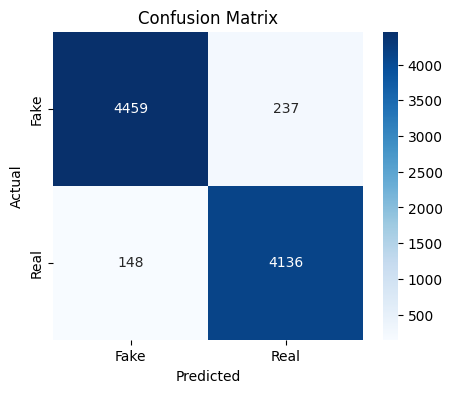

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, RocCurveDisplay

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define parameter grid
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0],   # smoothing values
    'fit_prior': [True, False]
}

# Initialize model
nb = MultinomialNB()

# GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(nb, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit on training data
grid_search.fit(X_train_tfidf, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best cross-validation accuracy
print("Best CV Accuracy:", grid_search.best_score_)

# Evaluate on test set
best_nb = grid_search.best_estimator_
y_pred = best_nb.predict(X_test_tfidf)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'alpha': 0.1, 'fit_prior': True}
Best CV Accuracy: 0.9564286787319851
Test Accuracy: 0.9586859688195991

Confusion Matrix:
 [[4463  233]
 [ 138 4146]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96      4696
           1       0.95      0.97      0.96      4284

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980



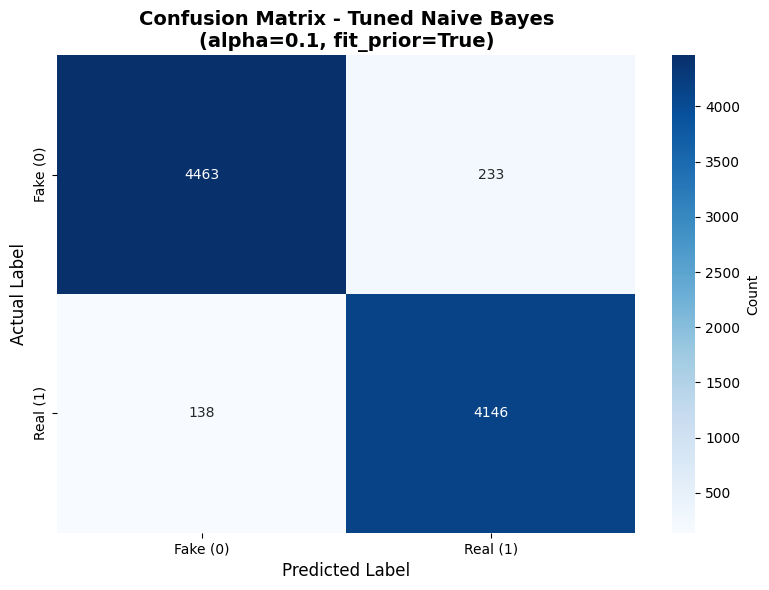


=== Performance Metrics for Tuned Model ===
True Negatives (Correctly identified Fake): 4463
False Positives (Fake predicted as Real): 233
False Negatives (Real predicted as Fake): 138
True Positives (Correctly identified Real): 4146

Accuracy: 0.9587
Precision (for Real news): 0.9468
Recall (for Real news): 0.9678


In [12]:
# Plot Confusion Matrix for Tuned Model
import matplotlib.pyplot as plt
import seaborn as sns

cm_tuned = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Fake (0)', 'Real (1)'], 
            yticklabels=['Fake (0)', 'Real (1)'],
            cbar_kws={'label': 'Count'})
plt.title(f"Confusion Matrix - Tuned Naive Bayes\n(alpha={grid_search.best_params_['alpha']}, fit_prior={grid_search.best_params_['fit_prior']})", 
          fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.tight_layout()
plt.show()

# Print additional metrics
print("\n=== Performance Metrics for Tuned Model ===")
print(f"True Negatives (Correctly identified Fake): {cm_tuned[0,0]}")
print(f"False Positives (Fake predicted as Real): {cm_tuned[0,1]}")
print(f"False Negatives (Real predicted as Fake): {cm_tuned[1,0]}")
print(f"True Positives (Correctly identified Real): {cm_tuned[1,1]}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (for Real news): {cm_tuned[1,1]/(cm_tuned[1,1]+cm_tuned[0,1]):.4f}")
print(f"Recall (for Real news): {cm_tuned[1,1]/(cm_tuned[1,1]+cm_tuned[1,0]):.4f}")
